## Install required packages

In [10]:
%pip install pandas numpy shap pyreadstat matplotlib xgboost imbalanced-learn --q

Note: you may need to restart the kernel to use updated packages.


## Import required libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay, precision_recall_curve
from sklearn.model_selection import RandomizedSearchCV
from sklearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.ensemble import BalancedRandomForestClassifier
import xgboost as xgb
import shap

c:\Users\xavie\Desktop\Universitá\2nd year\BDOS\project\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Load data

In [2]:
file_path = "37816-0001-Data.sav"

cols_needed = [
    # Target
    "VS0013", "VS0136", "VS0139", "VS0140", "VS0137", 
    "VS0138",
    # Demographics
    "V3014", "V3018", "SC214A", "V2038", "V3023A", "V2126B",
    # Crime & Environment
    "VS0133", "VS0130", "VS0112", # Gangs, Weapons, Hate   "VS0058", "VS0059",
    "SCS230", "SCS231", "SCS232", "SCS233", "SCS234", # Specific Drugs
    "VS0046", "VS0049", # Distraction, Rules
    "SCS212", "SCS213", # Perception
    # Social Support
    "VS0146", "VS0148", "SCS186", "SCS187",
    # Behavioral Reactions
    "VS0072", # Fights
    "VS0123", "VS0122", # Stayed home/Avoided class due to fear
    "VS0113", "VS0114", "VS0115", "VS0116", "VS0117", "VS0118", # Avoidance locations
    "VS0073", "VS0074", "VS0075", "VS0076" # Bullying
]

df = pd.read_spss(file_path, usecols=cols_needed, convert_categoricals=False)
df_text = pd.read_spss(file_path, usecols=['V2038'], convert_categoricals=True)
df['education_raw'] = df_text['V2038']

### Preprocessing

In [4]:
# Target: Dropout
# Status
cond_not_in_school = (df['VS0013'] == 2)

# Disengagement (No plans or chronic skipping)
cond_no_plans = (df['VS0139'].isin([2, 3])) | (df['VS0140'].isin([2, 3]))
cond_chronic_skip = (df['VS0137'].fillna(0) > 2) # More than 2 days skipped

dropout_mask = (cond_not_in_school | cond_no_plans | cond_chronic_skip)
df['dropout_risk'] = np.where(dropout_mask, 1, 0)

print(f"Target Distribution")
print(df['dropout_risk'].value_counts())
print(f"Risk Percentage: {df['dropout_risk'].mean():.2%}")

# Demographics

# Income
df['income'] = df['SC214A'].where(df['SC214A'].between(1, 17), np.nan)

# Sex
df['sex'] = np.where(df['V3018'] == 1, "Male", "Female")

# Race/Ethnicity
race_map = {
    1: "White", 
    2: "Black", 
    3: "Native American", 
    4: "Asian"
}
# Race > 5 (Mixed) are grouped into "Mixed/Other" to reduce sparsity
df['race'] = df['V3023A'].map(race_map)
df['race'] = df['race'].fillna("Missing")

# Simplify rare mixed categories
df.loc[~df['V3023A'].isin([1, 2, 3, 4]), 'race'] = "Mixed/Other"

# Age Groups
conditions_age = [df['V3014'].isin([12, 13]), df['V3014'].isin([14, 15, 16]), df['V3014'].isin([17, 18])]
df['age_group'] = np.select(conditions_age, ["12-13", "14-16", "17-18"], default="Missing")

# Parent Education
def clean_education(val):
    val = str(val)
    if "Residue" in val: return "Missing"
    if "Elementary" in val: return "Elementary"
    if any(x in val for x in ["High school", "12th grade", "Some college"]): return "HighSchool"
    if any(x in val for x in ["College", "degree", "Bachelor", "Master", "Doctorate"]): return "Bachelor+"
    return "Missing"
df['parent_education'] = df['education_raw'].apply(clean_education)

# Grades
# grade_map = {1: "A", 2: "B", 3: "C", 4: "D", 5: "F"}
# df['grades'] = df['VS0138'].map(grade_map).fillna("Missing")
grade_map_num = {1: 1, 2: 2, 3: 3, 4: 4, 5: 5} 
df['grades'] = df['VS0138'].map(grade_map_num)


# Drug Exposure
drug_cols = ["SCS230", "SCS231", "SCS232", "SCS233", "SCS234"]
df['drug_exposure_score'] = df[drug_cols].replace({2:0}).fillna(0).sum(axis=1)

# Violence Exposure (Gangs, Weapons, Hate)
violence_cols = ["VS0133", "VS0130", "VS0112"]
df['violence_exposure_score'] = df[violence_cols].replace({2:0}).fillna(0).sum(axis=1)

# # Bullying Score
# bully_cols = ["VS0073", "VS0074", "VS0076"] 
# df['bullying_score'] = df[bully_cols].replace({2:0}).fillna(0).sum(axis=1)

# # Fear-Based Behaviors
# fear_cols = ["VS0123", "VS0122"] # Stayed home, Avoided class
# df['fear_behavior_score'] = df[fear_cols].replace({2:0}).fillna(0).sum(axis=1)

# Isolation Score
support_cols = ["VS0146", "VS0148", "SCS186", "SCS187"]
df['total_isolation_score'] = df[support_cols].sum(axis=1)

# Avoidance Score (Location based)
avoid_cols = ["VS0113", "VS0114", "VS0115", "VS0116", "VS0117", "VS0118"]
df['avoidance_score'] = df[avoid_cols].replace({2:0}).fillna(0).sum(axis=1)

# Perceptions
df['crime_neighborhood'] = np.where(df['SCS212'].isin([1, 2]), "Agree", "Disagree")
df['crime_school'] = np.where(df['SCS213'].isin([1, 2]), "Agree", "Disagree")

Target Distribution
dropout_risk
0    12367
1     1906
Name: count, dtype: int64
Risk Percentage: 13.35%


In [5]:
features_num = [
    'income', 'grades',
    'drug_exposure_score', 'violence_exposure_score', 
    'total_isolation_score', 'avoidance_score', 
] #fear_behavior_score'
features_cat = [
    'sex', 'race', 'age_group', 'parent_education',
    'crime_neighborhood', 'crime_school'
]

X = df[features_num + features_cat].copy()
y = df['dropout_risk']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42, stratify=y)

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    # ('imputer', SimpleImputer(strategy='constant', fill_value=-1)),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='Missing')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', drop='first')) 
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, features_num),
        ('cat', categorical_transformer, features_cat)
    ])

### EDA

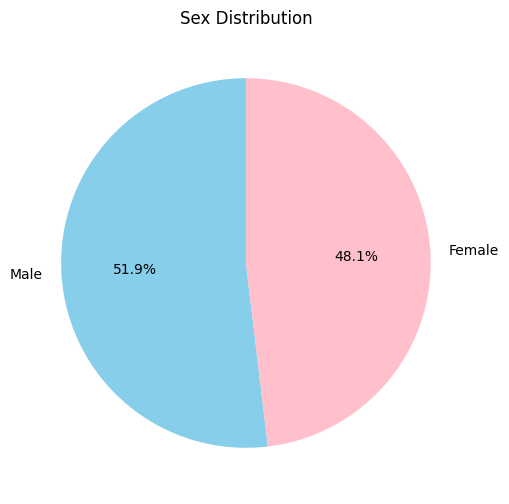

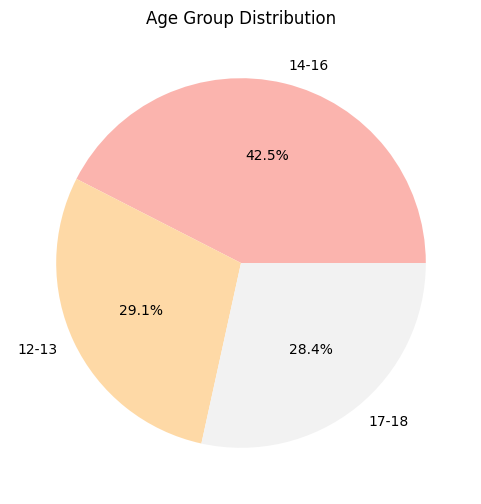

Grades distribution (%):
grades
1.0    47.79
2.0    39.57
3.0    11.05
4.0     1.08
5.0     0.51
Name: proportion, dtype: float64


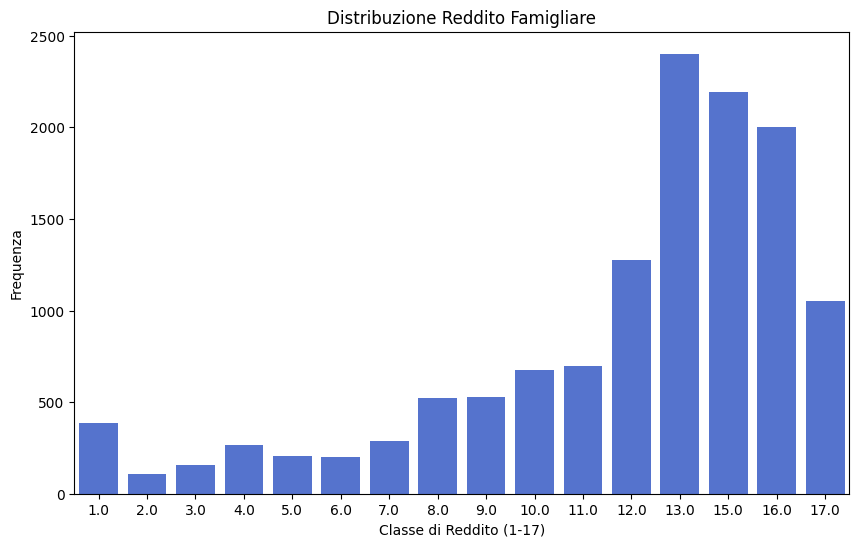

C:\Users\xavie\AppData\Local\Temp\ipykernel_30596\3748240008.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='parent_education', data=df, order=order_edu, palette="Set2", edgecolor="black")


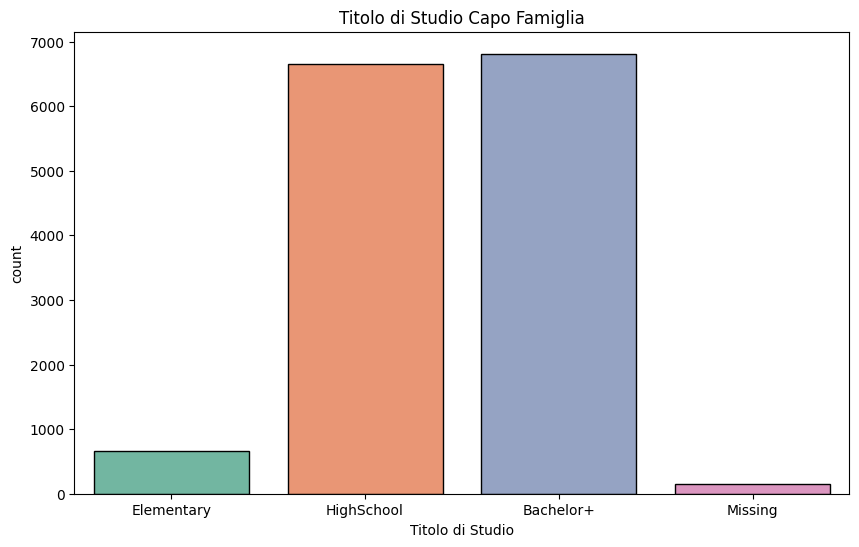

C:\Users\xavie\AppData\Local\Temp\ipykernel_30596\3748240008.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='dropout_label', data=df, palette=custom_palette, edgecolor="black")


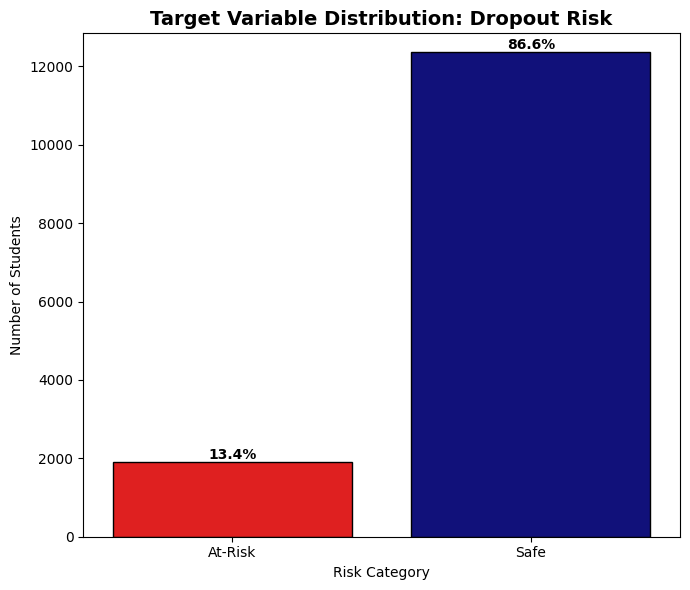

In [5]:
import seaborn as sns
df['dropout_label'] = df['dropout_risk'].map({0: 'Safe', 1: 'At-Risk'})

# Gender Distribution
plt.figure(figsize=(6, 6))
df['sex'].value_counts().plot.pie(autopct='%1.1f%%', colors=['skyblue', 'pink'], startangle=90)
plt.title("Sex Distribution")
plt.ylabel("")
plt.show()

# Age Group Distribution
plt.figure(figsize=(6, 6))
df['age_group'].value_counts().plot.pie(autopct='%1.1f%%', cmap="Pastel1")
plt.title("Age Group Distribution")
plt.ylabel("")
plt.show()

# Grades Distribution Table
print("Grades distribution (%):")
print(df['grades'].value_counts(normalize=True).mul(100).round(2))

# Income Distribution
plt.figure(figsize=(10, 6))
sns.countplot(x='income', data=df, color="royalblue")
plt.title("Distribuzione Reddito Famigliare")
plt.xlabel("Classe di Reddito (1-17)")
plt.ylabel("Frequenza")
plt.show()

# Head of Household Education Distribution
order_edu = ['Elementary', 'HighSchool', 'Bachelor+', 'Missing']
plt.figure(figsize=(10, 6))
sns.countplot(x='parent_education', data=df, order=order_edu, palette="Set2", edgecolor="black")
plt.title("Titolo di Studio Capo Famiglia")
plt.xlabel("Titolo di Studio")
plt.show()

# Target Variable Distribution: Dropout Risk
plt.figure(figsize=(7, 6))
custom_palette = {'Safe': 'darkblue', 'At-Risk': 'red'}
ax = sns.countplot(x='dropout_label', data=df, palette=custom_palette, edgecolor="black")
plt.title("Target Variable Distribution: Dropout Risk", fontsize=14, fontweight='bold')
plt.xlabel("Risk Category")
plt.ylabel("Number of Students")

total = len(df)
for p in ax.patches:
    count = int(p.get_height())
    percentage = '{:.1f}%'.format(100 * count / total)
    x = p.get_x() + p.get_width() / 2
    y = p.get_height()
    
    ax.annotate(f'{percentage}', (x, y), 
                ha='center', va='bottom', 
                fontsize=10, fontweight='bold', color='black')

plt.ylim(0, total * 0.9) 
plt.tight_layout()
plt.show()

## Logistic Regression

In [6]:
# Logistic Regression with SMOTE to handle the class imbalance
pipeline = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('classifier', LogisticRegression(max_iter=2000))
])

# Training
print("Training Logistic Regression")
pipeline.fit(X_train, y_train)

# Predict
y_pred = pipeline.predict(X_test)
y_prob = pipeline.predict_proba(X_test)[:, 1]

# Metrics
print(f"\nROC-AUC Score: {roc_auc_score(y_test, y_prob):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Training Logistic Regression

ROC-AUC Score: 0.8336

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.77      0.85      1237
           1       0.34      0.79      0.48       191

    accuracy                           0.77      1428
   macro avg       0.65      0.78      0.67      1428
weighted avg       0.88      0.77      0.80      1428



## Balanced Random Forest

Training Balanced RF

Results (Optimized Threshold: 0.64)
              precision    recall  f1-score   support

           0       0.95      0.88      0.91      1237
           1       0.46      0.68      0.55       191

    accuracy                           0.85      1428
   macro avg       0.70      0.78      0.73      1428
weighted avg       0.88      0.85      0.86      1428

AUC-ROC: 0.8826


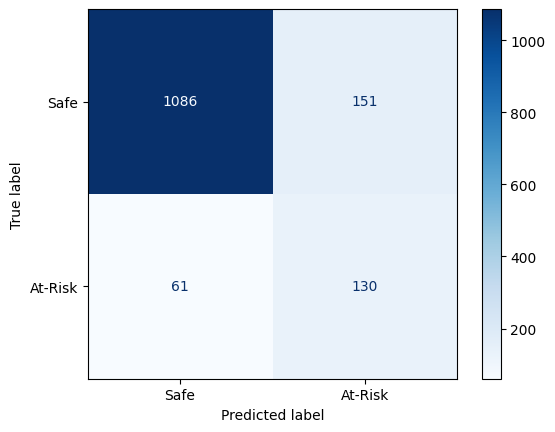

In [9]:
# Balanced Random Forest (robust to imbalance)
brf_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', BalancedRandomForestClassifier(
        n_estimators=400,
        max_depth=10,
        sampling_strategy='all',
        replacement=True, 
        random_state=42
    ))
])

# Training
print("Training Balanced RF")
brf_model.fit(X_train, y_train)

# Predict
y_prob = brf_model.predict_proba(X_test)[:, 1]

# Threshold tuning for best F1
precision, recall, thresholds = precision_recall_curve(y_test, y_prob)
f1_scores = 2 * (precision * recall) / (precision + recall)
best_threshold = thresholds[np.argmax(f1_scores)]

y_pred = (y_prob >= best_threshold).astype(int)

# Metrics
print(f"\nResults (Optimized Threshold: {best_threshold:.2f})")
print(classification_report(y_test, y_pred))
print(f"AUC-ROC: {roc_auc_score(y_test, y_prob):.4f}")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Safe', 'At-Risk'])
disp.plot(cmap='Blues')
plt.show()

### Tuning Balanced Random Forest

Tuning Balanced Random Forest Hyperparameters
Fitting 3 folds for each of 50 candidates, totalling 150 fits
Best Parameters: {'classifier__sampling_strategy': 'auto', 'classifier__replacement': True, 'classifier__n_estimators': 500, 'classifier__min_samples_leaf': 4, 'classifier__max_features': 'sqrt', 'classifier__max_depth': 10}

Optimal Threshold Analysis
Best Threshold: 0.7337
Best F1 Score: 0.5450
Recall at Best Threshold: 0.5550
Precision at Best Threshold: 0.5354

--- Final Optimized Results ---
              precision    recall  f1-score   support

           0       0.93      0.93      0.93      1237
           1       0.54      0.55      0.54       191

    accuracy                           0.88      1428
   macro avg       0.73      0.74      0.74      1428
weighted avg       0.88      0.88      0.88      1428

Final AUC-ROC: 0.8802


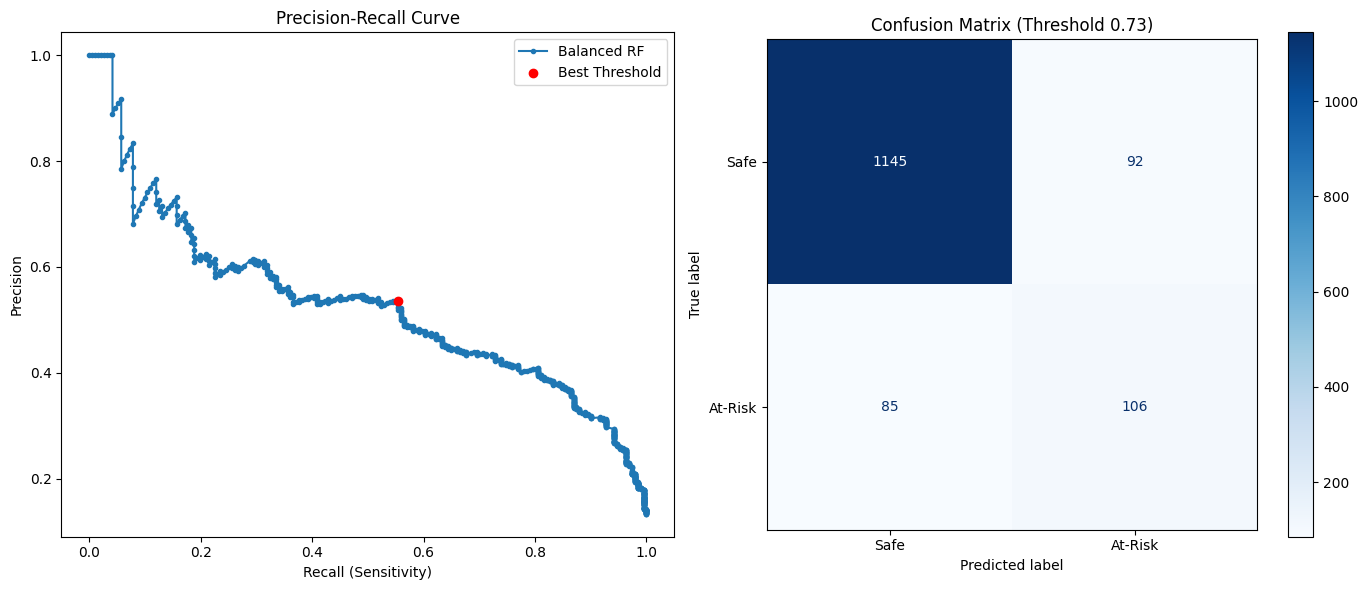

In [10]:
# Hyperparameter tuning
param_dist = {
    'classifier__n_estimators': [200, 300, 400, 500],
    'classifier__max_depth': [10, 15, 20, None],  # Deeper trees might capture more nuance
    'classifier__min_samples_leaf': [1, 2, 4, 8],    # Regularization
    'classifier__max_features': ['sqrt', 0.5],    # Feature sampling
    'classifier__sampling_strategy': ['auto', 0.8, 1.0], # Control ratio of majority:minority in bootstrap
    'classifier__replacement': [True, False]      # Sample with replacement?
}

# Re-create pipeline for tuning
pipeline_opt = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', BalancedRandomForestClassifier(random_state=42))
])

search = RandomizedSearchCV(
    pipeline_opt, 
    param_distributions=param_dist, 
    n_iter=50, 
    cv=3, 
    scoring='roc_auc', 
    n_jobs=-1, 
    random_state=42,
    verbose=1
)

print("Tuning Balanced Random Forest Hyperparameters")
search.fit(X_train, y_train)

best_model_opt = search.best_estimator_
print(f"Best Parameters: {search.best_params_}")

# Threshold optimization based on Precision-Recall curve

# Get probabilities
y_prob_opt = best_model_opt.predict_proba(X_test)[:, 1]

# Calculate Precision, Recall, and Thresholds
precision, recall, thresholds = precision_recall_curve(y_test, y_prob_opt)

# Calculate F1 Score for every possible threshold
f1_scores = 2 * (precision * recall) / (precision + recall)

# Handle division by zero
f1_scores = np.nan_to_num(f1_scores)

# Find the index of the best F1 score
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]
best_f1 = f1_scores[best_idx]

print(f"\nOptimal Threshold Analysis")
print(f"Best Threshold: {best_threshold:.4f}")
print(f"Best F1 Score: {best_f1:.4f}")
print(f"Recall at Best Threshold: {recall[best_idx]:.4f}")
print(f"Precision at Best Threshold: {precision[best_idx]:.4f}")

# Evaluation with optimal threshold
y_pred_opt = (y_prob_opt >= best_threshold).astype(int)

print("\n--- Final Optimized Results ---")
print(classification_report(y_test, y_pred_opt))
print(f"Final AUC-ROC: {roc_auc_score(y_test, y_prob_opt):.4f}")

# Visualizations
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Plot Precision-Recall Curve
ax1.plot(recall, precision, marker='.', label='Balanced RF')
ax1.scatter(recall[best_idx], precision[best_idx], marker='o', color='red', label='Best Threshold', zorder=5)
ax1.set_xlabel('Recall (Sensitivity)')
ax1.set_ylabel('Precision')
ax1.set_title('Precision-Recall Curve')
ax1.legend()

# Plot Confusion Matrix
cm = confusion_matrix(y_test, y_pred_opt)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Safe', 'At-Risk'])
disp.plot(cmap='Blues', ax=ax2)
ax2.set_title(f"Confusion Matrix (Threshold {best_threshold:.2f})")

plt.tight_layout()
plt.show()

## XGBoost

Calculated Scale Pos Weight: 6.49

Training and Tuning XGBoost...
Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best Params: {'classifier__subsample': 0.8, 'classifier__scale_pos_weight': np.float64(6.489795918367347), 'classifier__n_estimators': 300, 'classifier__min_child_weight': 10, 'classifier__max_depth': 3, 'classifier__learning_rate': 0.05, 'classifier__gamma': 0.2, 'classifier__colsample_bytree': 0.7}

 XGBoost Results (Optimized Threshold: 0.6716) 
              precision    recall  f1-score   support

           0       0.94      0.89      0.91      1237
           1       0.48      0.66      0.55       191

    accuracy                           0.86      1428
   macro avg       0.71      0.78      0.73      1428
weighted avg       0.88      0.86      0.87      1428

AUC-ROC: 0.8863


c:\Users\xavie\Desktop\Universitá\2nd year\BDOS\project\.venv\Lib\site-packages\xgboost\training.py:199: UserWarning: [22:56:02] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


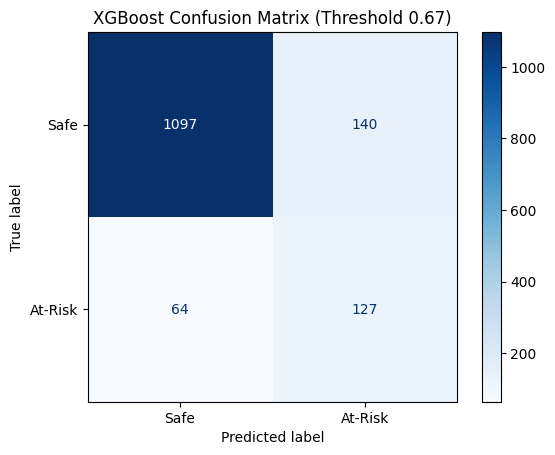

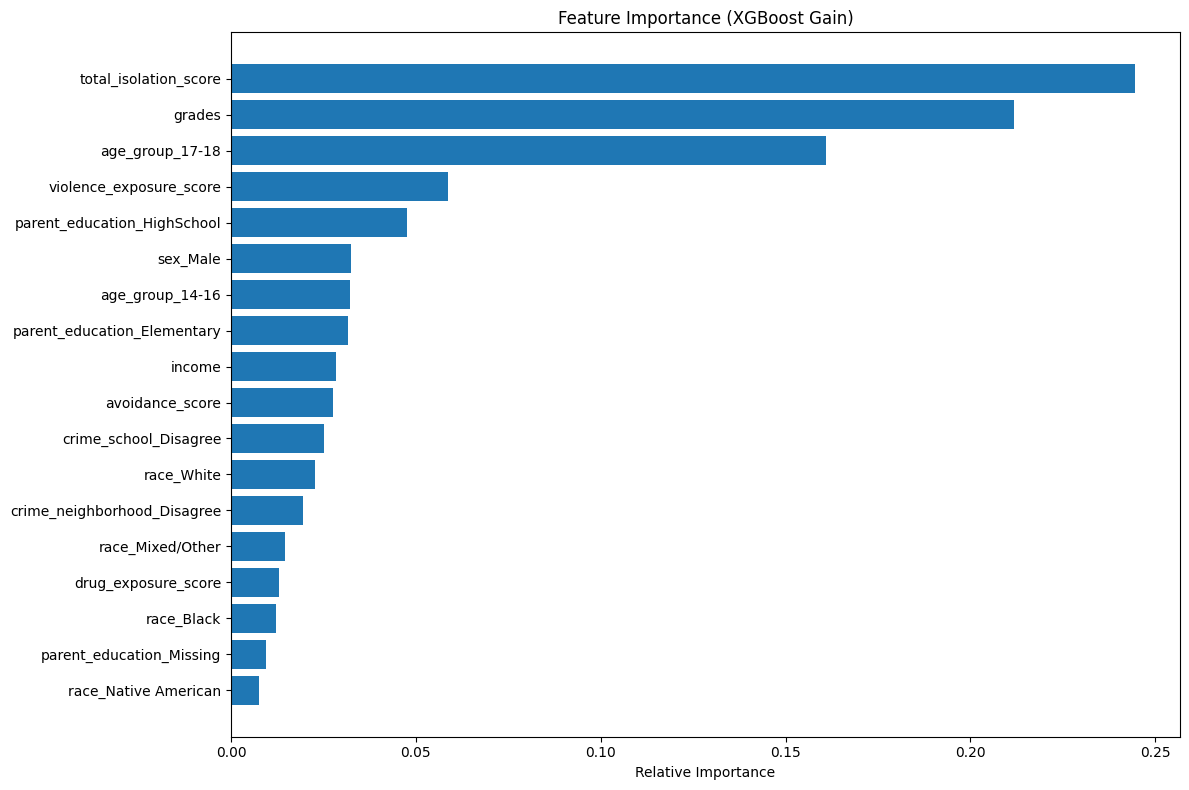

In [8]:
# Calculate the ratio for scale_pos_weight
# Logic: sum(negative) / sum(positive)
# This tells XGBoost: "Pay X times more attention to a dropout case than a non-dropout case"
ratio = float(np.sum(y_train == 0)) / np.sum(y_train == 1)
print(f"Calculated Scale Pos Weight: {ratio:.2f}")

xgb_clf = xgb.XGBClassifier(
    objective='binary:logistic',
    eval_metric='auc',
    use_label_encoder=False,
    random_state=42
)

# XGBoost has many parameters. We focus on those that control overfitting and balance.
param_dist = {
    'classifier__n_estimators': [100, 200, 300, 500],
    'classifier__learning_rate': [0.01, 0.05, 0.1, 0.001], # Slower learning rate = more robust
    'classifier__max_depth': [3, 5, 8, 10],             # Shallower trees prevent overfitting
    'classifier__min_child_weight': [1, 3, 5, 10],      # Similar to min_samples_leaf
    'classifier__gamma': [0, 0.1, 0.2, 0.5],             # Minimum loss reduction required to make a split
    'classifier__subsample': [0.7, 0.8, 1.0],       # Sample of rows
    'classifier__colsample_bytree': [0.7, 0.8, 1.0],# Sample of columns
    'classifier__scale_pos_weight': [ratio, ratio * 1.1, ratio * 0.9] # Tuning the weight slightly
}

pipeline_xgb = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', xgb_clf)
])

search = RandomizedSearchCV(
    pipeline_xgb, 
    param_distributions=param_dist, 
    n_iter=50, 
    cv=5, 
    scoring='roc_auc', 
    n_jobs=-1, 
    random_state=42,
    verbose=1
)

print("\nTraining and Tuning XGBoost...")
search.fit(X_train, y_train)

best_xgb = search.best_estimator_
print(f"Best Params: {search.best_params_}")

# Evalutation
y_prob = best_xgb.predict_proba(X_test)[:, 1]

# Find Optimal Threshold for F1
precision, recall, thresholds = precision_recall_curve(y_test, y_prob)
f1_scores = 2 * (precision * recall) / (precision + recall)
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]

print(f"\n XGBoost Results (Optimized Threshold: {best_threshold:.4f}) ")
y_pred_opt = (y_prob >= best_threshold).astype(int)
print(classification_report(y_test, y_pred_opt))
print(f"AUC-ROC: {roc_auc_score(y_test, y_prob):.4f}")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_opt)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Safe', 'At-Risk'])
disp.plot(cmap='Blues')
plt.title(f"XGBoost Confusion Matrix (Threshold {best_threshold:.2f})")
plt.show()

# Feature Importance

# Extract feature names
feature_names = (features_num + 
                 best_xgb.named_steps['preprocessor']
                 .named_transformers_['cat']
                 .named_steps['encoder']
                 .get_feature_names_out(features_cat).tolist())

# Get importance from the model itself (Gain)
importances = best_xgb.named_steps['classifier'].feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(12, 8))
plt.title('Feature Importance (XGBoost Gain)')
plt.barh(range(len(indices)), importances[indices], align='center')
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel('Relative Importance')
plt.tight_layout()
plt.show()

## Explenability

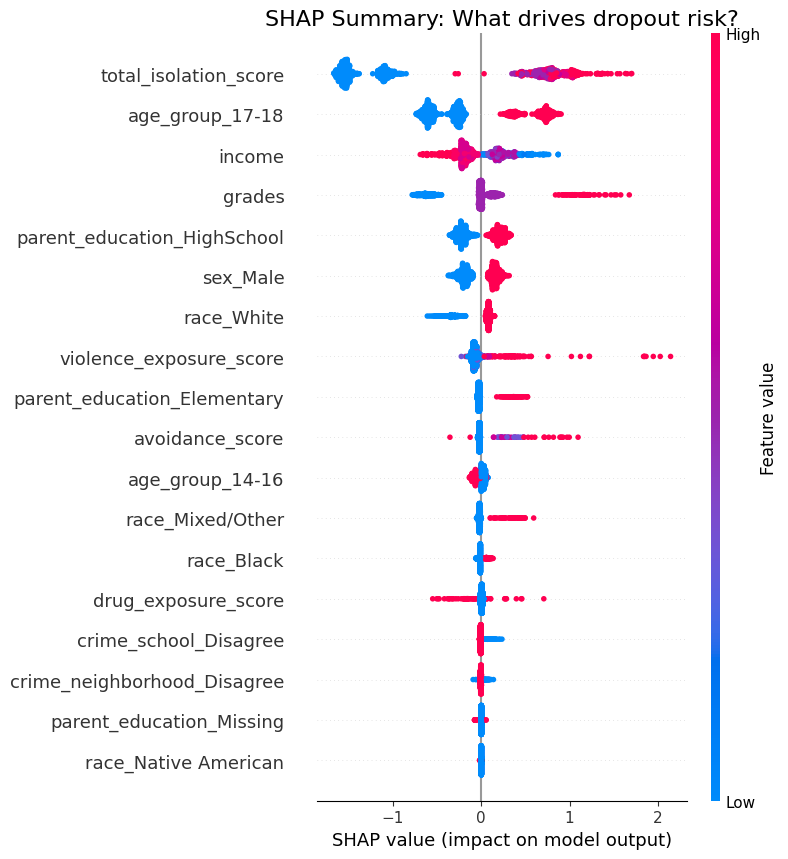

In [11]:
# Prepare data for SHAP
preprocessor_obj = best_xgb.named_steps['preprocessor']
X_test_transformed = preprocessor_obj.transform(X_test)
cat_encoder = preprocessor_obj.named_transformers_['cat']['encoder']
cat_feature_names = cat_encoder.get_feature_names_out(features_cat)
all_feature_names = features_num + list(cat_feature_names)

X_test_df = pd.DataFrame(X_test_transformed, columns=all_feature_names)

# SHAP values computation
model_obj = best_xgb.named_steps['classifier']
explainer = shap.TreeExplainer(model_obj)
shap_values = explainer.shap_values(X_test_df)

# Summary Plot
plt.figure(figsize=(12, 10))
shap.summary_plot(shap_values, X_test_df, show=False)
plt.title("SHAP Summary: What drives dropout risk?", fontsize=16)
plt.tight_layout()
plt.show()